## **011963 ML for Civil and Environmental Engineering**

#### **02. Probability and Statistics**
#### **Made by SSJin (2026.03.15)**
#### Sejong University, Dept. of Civil & Environmental Engineering

---

#### **0 - Understanding Random Variables**

> **Convention:**
> - <font color='blue'>**Blue = Example**</font>: Worked examples with complete code.
> - <font color='red'>**Red = Exercise**</font>: Fill in the blanks (`________`).
> - Answer keys are at the bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

##### **0.1 - Why Probability?**

In civil and environmental engineering, we deal with **uncertainty** everywhere:
- Material strength varies from specimen to specimen
- Environmental loads (wind, earthquake) are inherently random
- Sensor measurements contain noise

**Probability** provides the mathematical framework to quantify and manage this uncertainty.

##### **0.2 - Random Variables**

A **random variable** maps the outcomes of a random experiment to numerical values.

| Type | Description | Example |
|------|-------------|----------|
| **Discrete** | Countable outcomes | Number of cracks in a beam, dice roll |
| **Continuous** | Any value in an interval | Concrete strength (MPa), temperature (°C) |

##### **0.3 - Probability Mass Function (PMF)**

For **discrete** random variables, the PMF gives the probability that $X$ takes each specific value:

$$P(X = x_i) = p_i, \quad \sum_i p_i = 1$$

##### **0.4 - Probability Density Function (PDF)**

For **continuous** random variables, the PDF $f(x)$ defines probability as area under the curve:

$$P(a \leq X \leq b) = \int_a^b f(x)\,dx$$

> **Important**: For continuous distributions, $P(X = a) = 0$ for any single point. Only intervals have nonzero probability.

##### **0.5 - Cumulative Distribution Function (CDF)**

$$F(x) = P(X \leq x)$$

The CDF is the accumulated probability up to value $x$. It applies to both discrete and continuous random variables.

<font color='blue'>**Example) Visualize the CDF of a standard normal distribution from random samples**</font>

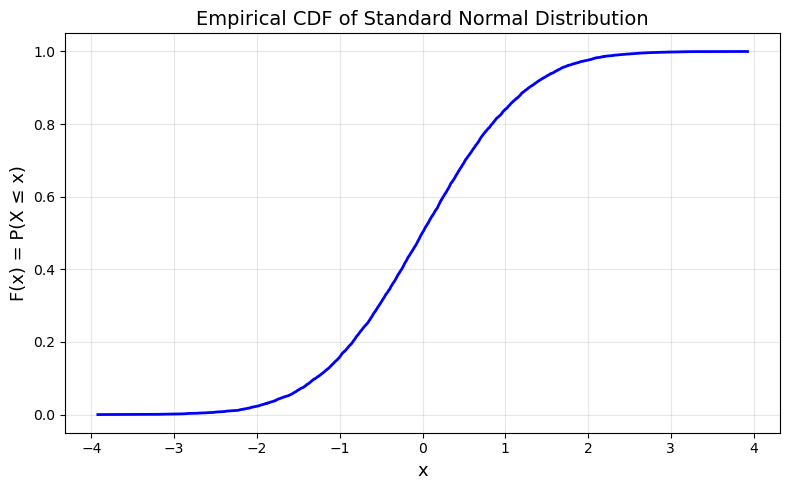

In [2]:
samples = np.random.normal(0, 1, 10000)
sorted_samples = np.sort(samples)
cdf_y = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)

plt.figure(figsize=(8, 5))
plt.plot(sorted_samples, cdf_y, 'b-', linewidth=2)
plt.xlabel('x', fontsize=13)
plt.ylabel('F(x) = P(X ≤ x)', fontsize=13)
plt.title('Empirical CDF of Standard Normal Distribution', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
#### **1 - Probability and Statistics in Data Science**

##### **1.1 - Definition of Probability**

**Probability** quantifies how likely an event is to occur, expressed as a number between 0 and 1:

$$P(A) = \frac{\text{Number of favorable outcomes}}{\text{Total number of outcomes}}$$

##### **1.2 - Complementary Events**

$$P(A^c) = 1 - P(A)$$

If the probability of a die landing on 5 is $\frac{1}{6}$, then the probability of NOT landing on 5 is $1 - \frac{1}{6} = \frac{5}{6}$.

##### **1.3 - Convergence to Probability (Law of Large Numbers)**

As the number of trials increases, the observed relative frequency converges to the theoretical probability.

<font color='blue'>**Example) Simulate 5000 die rolls and show convergence to $P(5)=1/6$**</font>

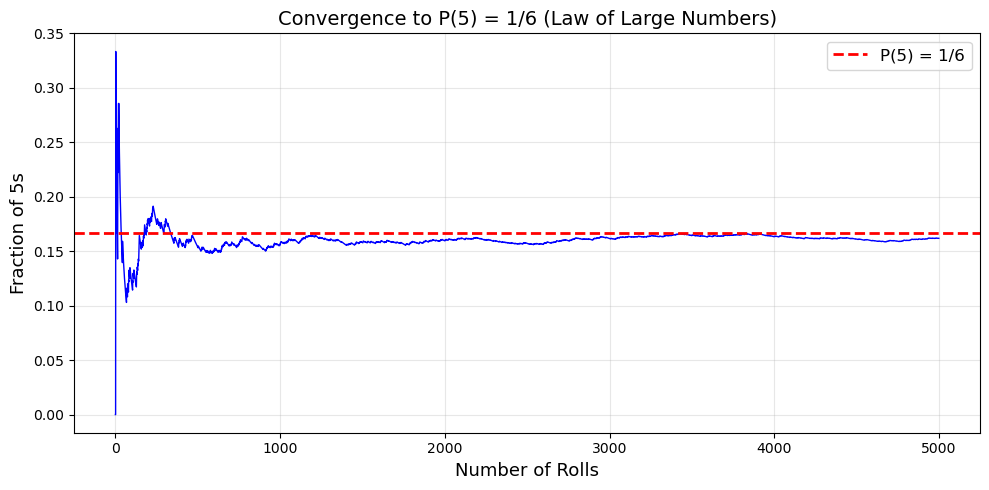

In [3]:
x_axis = []
y_axis = []
total = 0
num_5 = 0
n = 5000

for i in range(n):
    if np.random.randint(6) + 1 == 5:
        num_5 += 1
    total += 1
    x_axis.append(i)
    y_axis.append(num_5 / total)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, y_axis, 'b-', linewidth=1)
plt.axhline(y=1/6, color='r', linestyle='--', linewidth=2, label='P(5) = 1/6')
plt.xlabel('Number of Rolls', fontsize=13)
plt.ylabel('Fraction of 5s', fontsize=13)
plt.title('Convergence to P(5) = 1/6 (Law of Large Numbers)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<font color='red'>**Exercise 1.1) Simulate 5000 coin flips and verify convergence to $P(\text{Heads}) = 1/2$.**</font>

Fill in the blanks to complete the simulation.

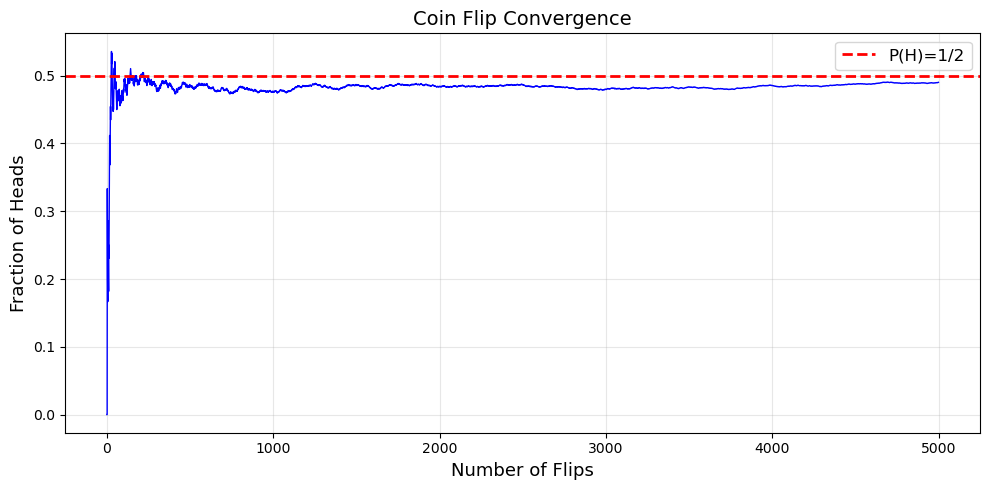

In [7]:
x_axis = []
y_axis = []
total = 0
num_heads = 0
n = 5000

for i in range(n):
    if np.random.randint(2) == 0:
        num_heads += 1
    total += 1
    x_axis.append(i)
    y_axis.append(num_heads / total)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, y_axis, 'b-', linewidth=1)
plt.axhline(y=1/2, color='r', linestyle='--', linewidth=2, label='P(H)=1/2')  # theoretical
plt.xlabel('Number of Flips', fontsize=13)
plt.ylabel('Fraction of Heads', fontsize=13)
plt.title('Coin Flip Convergence', fontsize=14)
plt.legend(fontsize=12); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
#### **2 - Average and Expected Value**

##### **2.1 - Average (Mean)**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

<font color='blue'>**Example) Compute the average using `np.average()`**</font>

In [8]:
x = np.array([55, 45, 60, 40])
print(f'Average: {np.average(x)}')

Average: 50.0


##### **2.2 - Expected Value**

The expected value is the **probability-weighted** average:

$$E[X] = \sum_{i} p_i \cdot x_i$$

<font color='blue'>**Example) Calculate expected value of a lottery**</font>

| Prize | $100 | $500 | $1000 |
|-------|------|------|-------|
| Probability | 0.80 | 0.15 | 0.05 |

In [9]:
p = np.array([0.80, 0.15, 0.05])  # probabilities
x = np.array([100, 500, 1000])    # values

E_X = np.sum(p * x)
print(f'Expected value: ${E_X:.2f}')

Expected value: $205.00


<font color='red'>**Exercise 2.1) Calculate the expected value for the following scenario.**</font>

| Prize | $100 | $500 | $10,000 |
|-------|------|------|--------|
| Probability | 0.75 | 0.23 | 0.02 |

In [10]:
p = np.array([0.75, 0.23, 0.02])
x = np.array([100, 500, 10000])

E_X = np.sum(p * x)
print(f'Expected value: ${E_X:.2f}')

Expected value: $390.00


##### **2.3 - Relationship: Average ↔ Expected Value**

As the number of samples increases, the **sample average** converges to the **expected value** (Law of Large Numbers).

---
#### **3 - Variance and Standard Deviation**

##### **3.1 - Variance**

Variance measures the **spread** of data around the mean:

$$\text{Var}(X) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

<font color='blue'>**Example) Compare variance of two datasets**</font>

In [11]:
x1 = np.array([55, 45, 60, 40])   # high spread
x2 = np.array([51, 49, 52, 48])   # low spread

print(f'x1: mean={np.mean(x1):.1f}, variance={np.var(x1):.2f}')
print(f'x2: mean={np.mean(x2):.1f}, variance={np.var(x2):.2f}')

x1: mean=50.0, variance=62.50
x2: mean=50.0, variance=2.50


##### **3.2 - Standard Deviation**

$$\sigma = \sqrt{\text{Var}(X)}$$

Standard deviation has the **same units** as the original data, making it more interpretable than variance.

In [12]:
print(f'x1: std={np.std(x1):.4f}')
print(f'x2: std={np.std(x2):.4f}')

x1: std=7.9057
x2: std=1.5811


---
#### **4 - Normal Distribution and Power Law**

##### **4.1 - Normal (Gaussian) Distribution**

The most important distribution in statistics:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

Properties:
- Bell-shaped, symmetric about $\mu$
- ~68% of data within $\mu \pm \sigma$
- ~95% within $\mu \pm 2\sigma$
- ~99.7% within $\mu \pm 3\sigma$

<font color='blue'>**Example) Draw normal distribution curves for different standard deviations**</font>

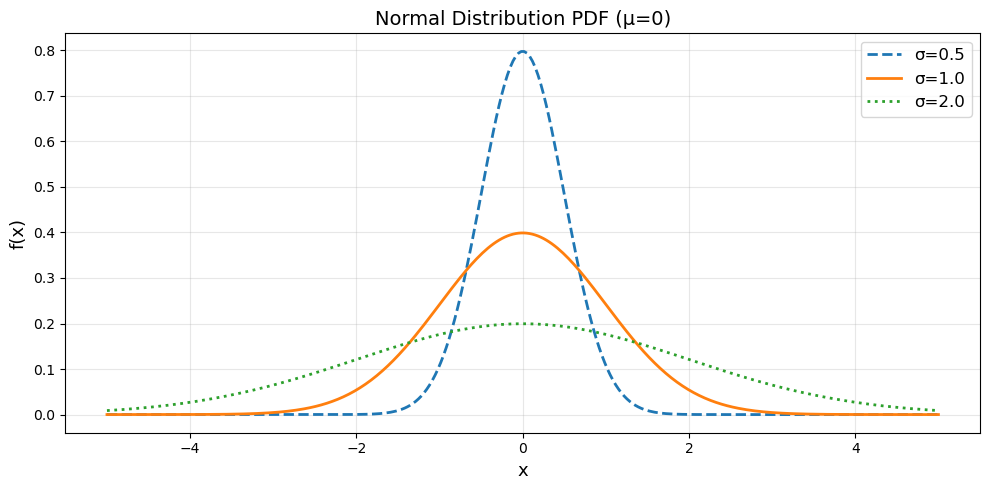

In [13]:
def pdf_normal(x, mu, sigma):
    return 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2 / (2*sigma**2))

x = np.linspace(-5, 5, 300)

plt.figure(figsize=(10, 5))
for sigma, style in [(0.5,'--'), (1.0,'-'), (2.0,':')]:
    plt.plot(x, pdf_normal(x, 0, sigma), style, linewidth=2, label=f'σ={sigma}')
plt.xlabel('x', fontsize=13); plt.ylabel('f(x)', fontsize=13)
plt.title('Normal Distribution PDF (μ=0)', fontsize=14)
plt.legend(fontsize=12); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

##### **4.2 - Generating Random Numbers from Normal Distribution**

<font color='blue'>**Example) Generate 10,000 random samples and plot histogram**</font>

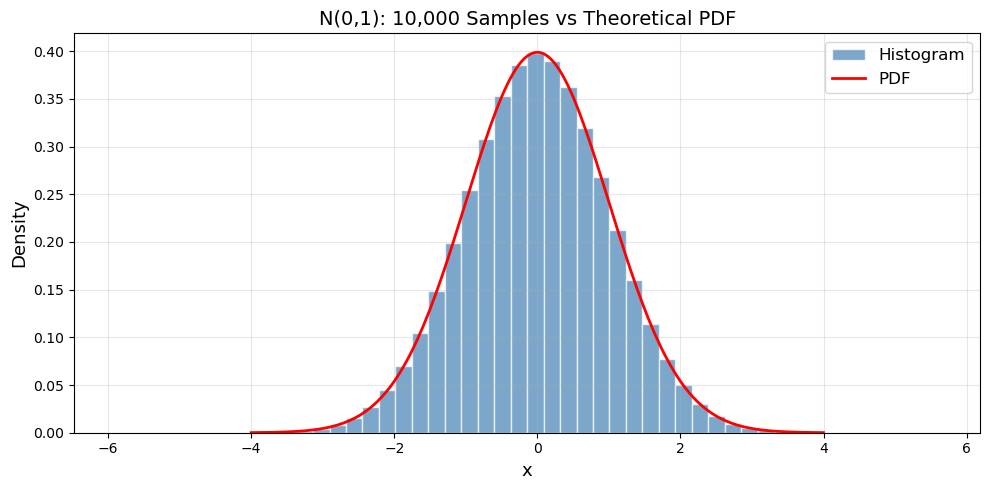

In [19]:
s = np.random.normal(0, 1, 100000000)

plt.figure(figsize=(10, 5))
plt.hist(s, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white', label='Histogram')
x_range = np.linspace(-4, 4, 200)
plt.plot(x_range, pdf_normal(x_range, 0, 1), 'r-', linewidth=2, label='PDF')
plt.xlabel('x', fontsize=13); plt.ylabel('Density', fontsize=13)
plt.title('N(0,1): 10,000 Samples vs Theoretical PDF', fontsize=14)
plt.legend(fontsize=12); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

##### **4.3 - Power Law**

Not all distributions are bell-shaped. **Power law** distributions have heavy tails:

$$f(x) = c \cdot x^{-k}$$

Examples: earthquake magnitudes, city populations, wealth distribution.

<font color='blue'>**Example) Power law curves and Pareto distribution**</font>

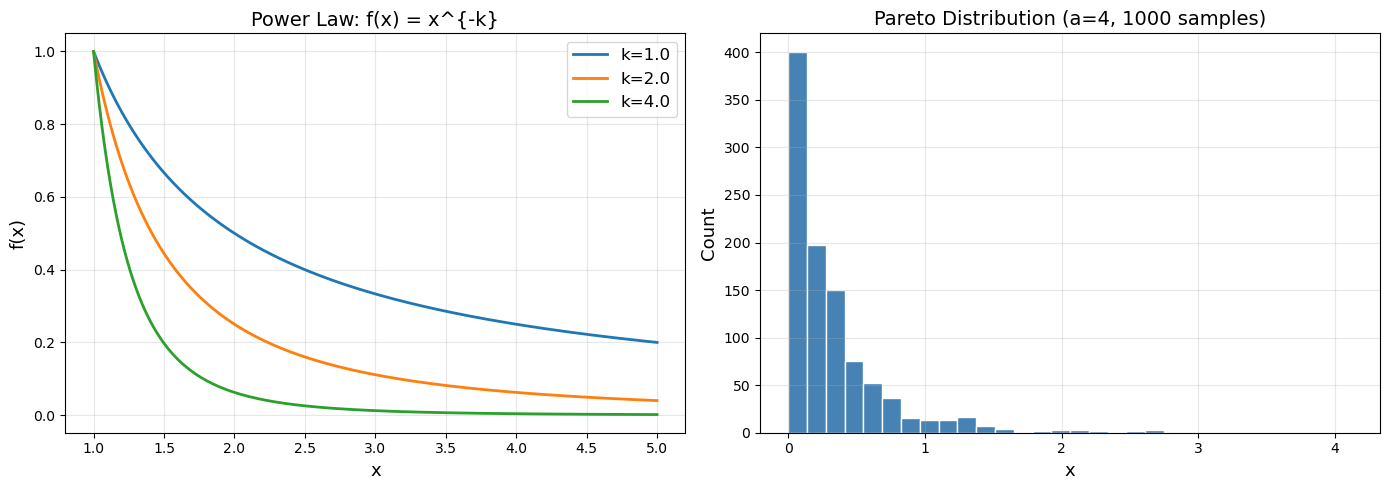

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Power law curves
x = np.linspace(1, 5, 200)
for k in [1.0, 2.0, 4.0]:
    axes[0].plot(x, x**(-k), linewidth=2, label=f'k={k}')
axes[0].set_xlabel('x', fontsize=13); axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Power Law: f(x) = x^{-k}', fontsize=14)
axes[0].legend(fontsize=12); axes[0].grid(True, alpha=0.3)

# Right: Pareto distribution samples
s = np.random.pareto(4, 1000)
axes[1].hist(s, bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel('x', fontsize=13); axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Pareto Distribution (a=4, 1000 samples)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

<font color='red'>**Exercise 4.1) Generate 1000 random numbers from N(0,1) and plot a histogram with the theoretical PDF overlaid.**</font>

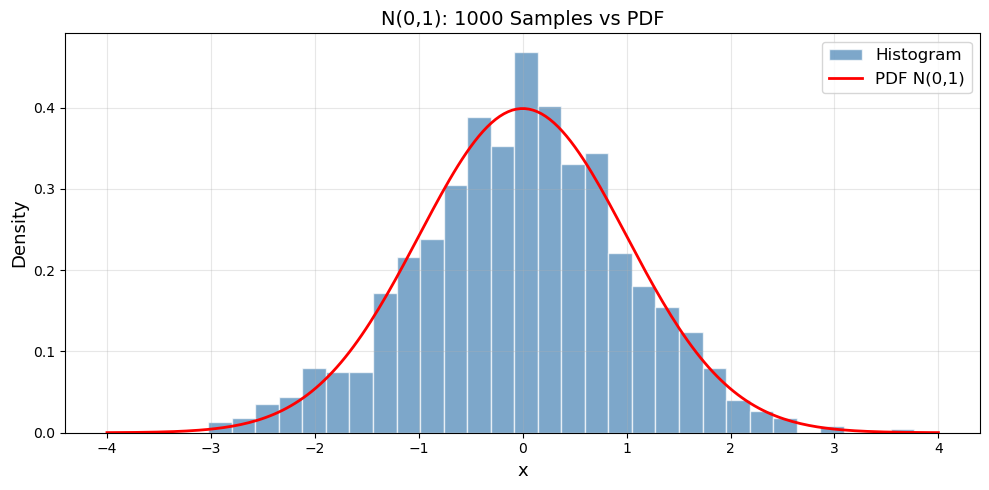

In [21]:
# Generate 1000 samples from N(0,1)
x_samples = np.random.normal(0, 1, 1000)

plt.figure(figsize=(10, 5))
plt.hist(x_samples, bins=30, density=True, alpha=0.7,
         color='steelblue', edgecolor='white', label='Histogram')

# Overlay PDF
x_range = np.linspace(-4, 4, 200)
plt.plot(x_range, pdf_normal(x_range, 0, 1),
         'r-', linewidth=2, label='PDF N(0,1)')

plt.xlabel('x', fontsize=13); plt.ylabel('Density', fontsize=13)
plt.title('N(0,1): 1000 Samples vs PDF', fontsize=14)
plt.legend(fontsize=12); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
#### **5 - Covariance**

##### **5.1 - Definition of Covariance**

Covariance measures the **joint variability** of two variables:

$$\text{Cov}(X, Y) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

| Cov(X,Y) | Interpretation |
|----------|----------------|
| > 0 | X and Y tend to increase together |
| < 0 | When X increases, Y tends to decrease |
| ≈ 0 | No linear relationship |

##### **5.2 - Example: Student Exam Scores**

<font color='blue'>**Example) Compute covariance between Math-English and Math-Korean scores**</font>

Cov(Math, English) =  120.00  (positive → move together)
Cov(Math, Korean)  = -160.00  (negative → move oppositely)


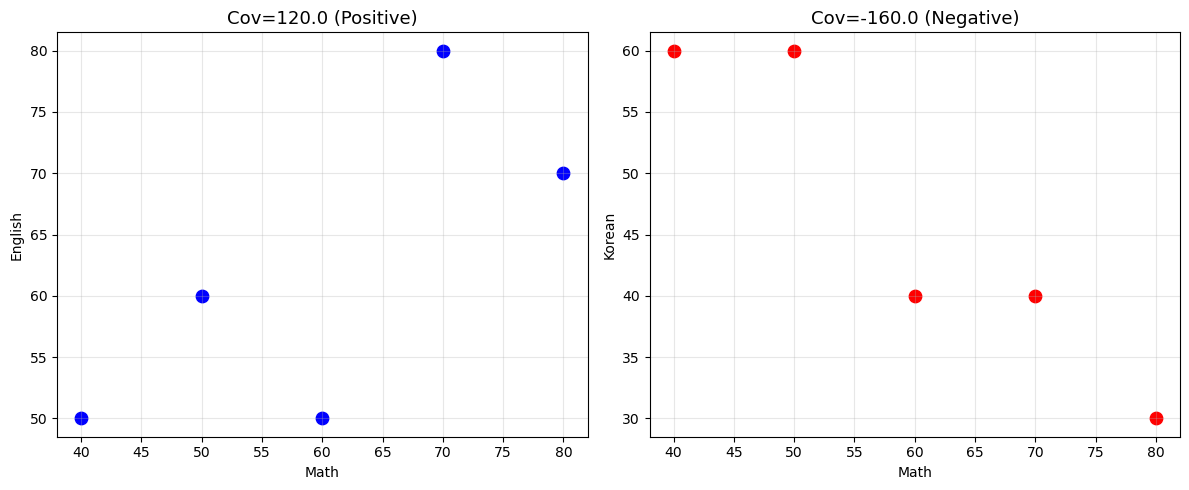

In [22]:
x = np.array([50, 70, 40, 60, 80])  # Math
y = np.array([60, 80, 50, 50, 70])  # English
z = np.array([60, 40, 60, 40, 30])  # Korean

cov_xy = np.mean((x - np.mean(x)) * (y - np.mean(y)))
cov_xz = np.mean((x - np.mean(x)) * (z - np.mean(z)))

print(f'Cov(Math, English) = {cov_xy:>7.2f}  (positive → move together)')
print(f'Cov(Math, Korean)  = {cov_xz:>7.2f}  (negative → move oppositely)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(x, y, s=80, color='blue'); axes[0].set_xlabel('Math'); axes[0].set_ylabel('English')
axes[0].set_title(f'Cov={cov_xy:.1f} (Positive)', fontsize=13); axes[0].grid(True, alpha=0.3)
axes[1].scatter(x, z, s=80, color='red'); axes[1].set_xlabel('Math'); axes[1].set_ylabel('Korean')
axes[1].set_title(f'Cov={cov_xz:.1f} (Negative)', fontsize=13); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

##### **5.3 - Covariance Matrix**

For multivariate data, the **covariance matrix** $C$ captures all pairwise covariances:

$$C = \begin{bmatrix} \text{Var}(X) & \text{Cov}(X,Y) \\ \text{Cov}(Y,X) & \text{Var}(Y) \end{bmatrix}$$

##### **5.4 - Generating Data from a Covariance Matrix**

<font color='blue'>**Example) Visualize how covariance affects data distribution**</font>

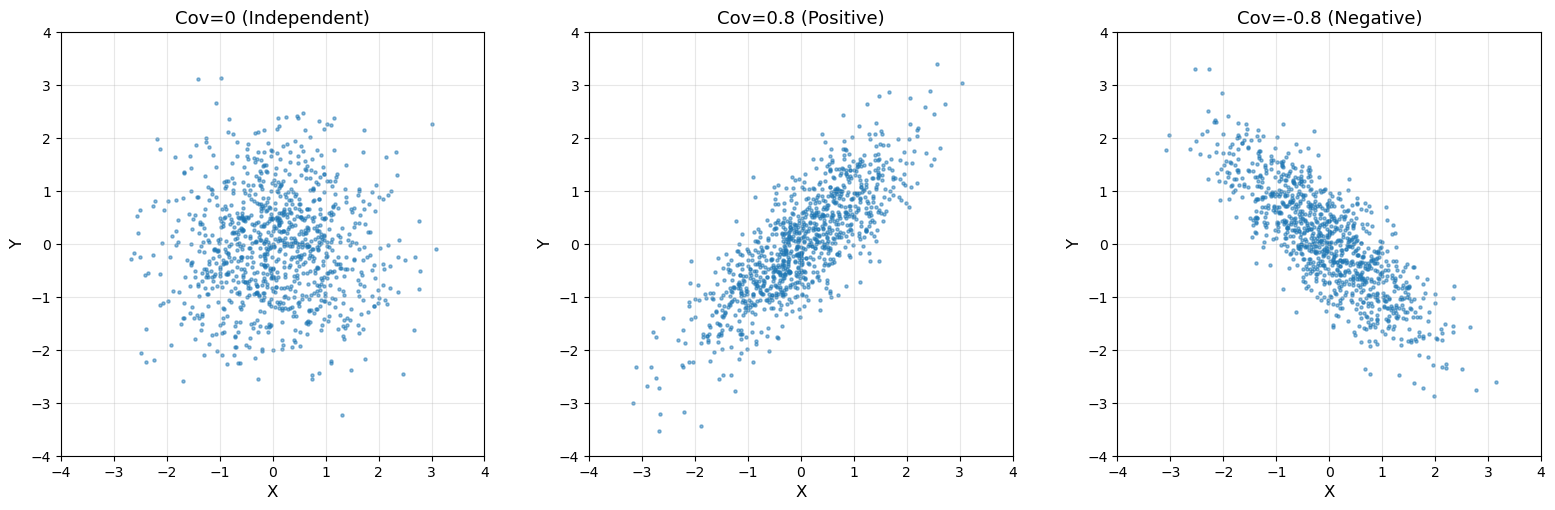

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
covs = [0.0, 0.8, -0.8]
titles = ['Cov=0 (Independent)', 'Cov=0.8 (Positive)', 'Cov=-0.8 (Negative)']

for ax, cov, title in zip(axes, covs, titles):
    mean = [0, 0]
    cov_matrix = [[1, cov], [cov, 1]]
    data = np.random.multivariate_normal(mean, cov_matrix, 1000)
    ax.scatter(data[:,0], data[:,1], s=5, alpha=0.5)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_xlabel('X', fontsize=12); ax.set_ylabel('Y', fontsize=12)
    ax.set_title(title, fontsize=13); ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

<font color='red'>**Exercise 5.1) Compute the covariance of World History and Korean History scores.**</font>

Cov(World Hist, Korean Hist) = 380.00


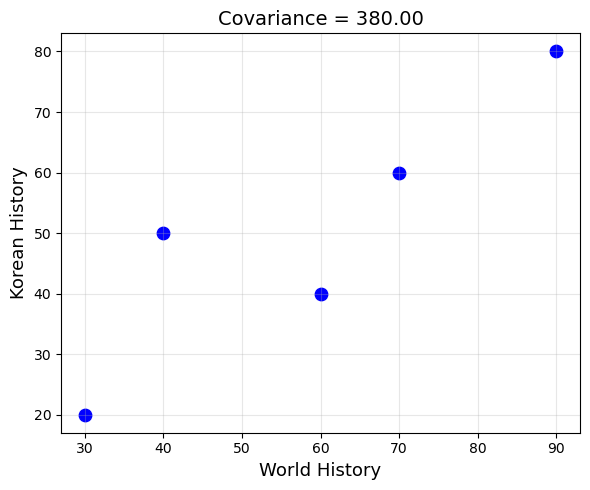

In [24]:
x = np.array([30, 70, 40, 60, 90])  # World History
y = np.array([20, 60, 50, 40, 80])  # Korean History

cov_xy = np.mean((x- np.mean(x))* (y - np.mean(y)))
print(f'Cov(World Hist, Korean Hist) = {cov_xy:.2f}')

plt.figure(figsize=(6, 5))
plt.scatter(x, y, s=80, color='blue', marker='o')
plt.xlabel('World History', fontsize=13)
plt.ylabel('Korean History', fontsize=13)
plt.title(f'Covariance = {cov_xy:.2f}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
#### **6 - Correlation Coefficient**

##### **6.1 - Definition**

The **Pearson correlation coefficient** normalizes covariance to $[-1, +1]$:

$$r_{XY} = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

| $r$ | Interpretation |
|-----|----------------|
| +1 | Perfect positive linear relationship |
| 0 | No linear relationship |
| -1 | Perfect negative linear relationship |

##### **6.2 - Computing Correlation**

<font color='blue'>**Example) Correlation using `np.corrcoef()` and manual calculation**</font>

In [25]:
x = np.array([50, 70, 40, 60, 80])  # Math
y = np.array([60, 80, 50, 50, 70])  # English

# Method 1: np.corrcoef()
corr_matrix = np.corrcoef(x, y)
print(f'np.corrcoef:\n{corr_matrix}\n')

# Method 2: Manual
cov_xy = np.mean((x - np.mean(x)) * (y - np.mean(y)))
r_manual = cov_xy / (np.std(x) * np.std(y))
print(f'Manual: r = {r_manual:.6f}')

np.corrcoef:
[[1.         0.72760688]
 [0.72760688 1.        ]]

Manual: r = 0.727607


<font color='red'>**Exercise 6.1) Find the correlation coefficient for World History vs Korean History using both methods.**</font>

In [30]:
x = np.array([30, 70, 40, 60, 90])  # World History
y = np.array([20, 60, 50, 40, 80])  # Korean History

# Method 1: np.corrcoef()
print('np.corrcoef:')
print(np.corrcoef(x, y))

# Method 2: Manual (cov / (std_x * std_y))
cov_xy = np.mean((x - np.mean(x)) * (y - np.mean(y)))
r_manual = cov_xy / (np.std(x) * np.std(y))
print(f'\nManual: r = {r_manual:.6f}')

np.corrcoef:
[[1.         0.88975652]
 [0.88975652 1.        ]]

Manual: r = 0.889757


---
#### **7 - Conditional Probability and Bayes' Theorem**

##### **7.1 - Conditional Probability**

The probability of $A$ **given** $B$ has occurred:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

##### **7.2 - Example: Construction Defect Inspection**

A building inspector checks 200 construction sites:

| | Defect Found | No Defect | Total |
|---|---|---|---|
| **Large Project** | 30 | 70 | 100 |
| **Small Project** | 10 | 90 | 100 |
| **Total** | 40 | 160 | 200 |

<font color='blue'>**Example) Compute conditional probabilities from the table above**</font>

In [31]:
# P(Defect | Large Project)
P_defect_given_large = 30 / 100
print(f'P(Defect | Large) = {P_defect_given_large:.2f}')

# P(Large Project | Defect Found)
P_large_given_defect = 30 / 40
print(f'P(Large | Defect) = {P_large_given_defect:.2f}')

# P(Defect)
P_defect = 40 / 200
print(f'P(Defect) = {P_defect:.2f}')

P(Defect | Large) = 0.30
P(Large | Defect) = 0.75
P(Defect) = 0.20


##### **7.3 - Bayes' Theorem**

Bayes' theorem allows us to **update** our belief about $A$ after observing evidence $B$:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

| Term | Name | Meaning |
|------|------|---------|
| $P(A)$ | **Prior** | Initial belief before evidence |
| $P(B|A)$ | **Likelihood** | Probability of evidence given hypothesis |
| $P(A|B)$ | **Posterior** | Updated belief after evidence |
| $P(B)$ | **Evidence** | Total probability of the evidence |

베이즈 정리는 결국에는 $P(A|B)$를 구하는 것이다. 

B가 관찰됐을 때 A일 확률
&rarr; B는 이미 일어난 사건 (관측된 증거)
&rarr; A는 우리가 알고 싶은 것 (가설)

$P(B|A)$는 알고 있고 
$P(A|B)$를 모르는 상황!

$P(B|A)$ &rarr; 계산하기 쉬운 것
$P(A|B)$ &rarr; 실제로 알고 싶은 것

베이즈 정리 = 알기 쉬운 P(B|A) 로
              알고 싶은 P(A|B) 를 구하는 공식!

A = 환자가 병에 걸림
B = 검사 결과 양성

우리가 알고 싶은 것:
P(A|B) = 양성이 나왔을 때 진짜 병에 걸렸을 확률

알고 있는 것:
P(B|A) = 병에 걸렸을 때 양성 나올 확률 (검사 정확도)
P(A)   = 원래 병에 걸릴 확률 (사전 확률)
P(B)   = 양성 나올 전체 확률


##### **7.4 - Bayes' Theorem Application**

<font color='blue'>**Example) Medical test: Sensitivity = 99%, Specificity = 95%, Prevalence = 1%**</font>

If a patient tests positive, what is the actual probability they have the disease?

In [2]:
# Given
sensitivity = 0.99   # P(Positive | Disease)
specificity = 0.95   # P(Negative | No Disease)
prevalence  = 0.01   # P(Disease)

# Bayes' Theorem
P_positive = sensitivity * prevalence + (1 - specificity) * (1 - prevalence)
P_disease_given_positive = (sensitivity * prevalence) / P_positive

print(f'P(Positive)           = {P_positive:.4f}')
print(f'P(Disease | Positive) = {P_disease_given_positive:.4f}')
print(f'\nDespite 99% sensitivity, a positive test only means')
print(f'a {P_disease_given_positive*100:.1f}% chance of actually having the disease!')
print(f'This is because the disease is rare (1% prevalence).')

P(Positive)           = 0.0594
P(Disease | Positive) = 0.1667

Despite 99% sensitivity, a positive test only means
a 16.7% chance of actually having the disease!
This is because the disease is rare (1% prevalence).


<font color='blue'>**Example) Bayesian updating with Beta distribution**</font>

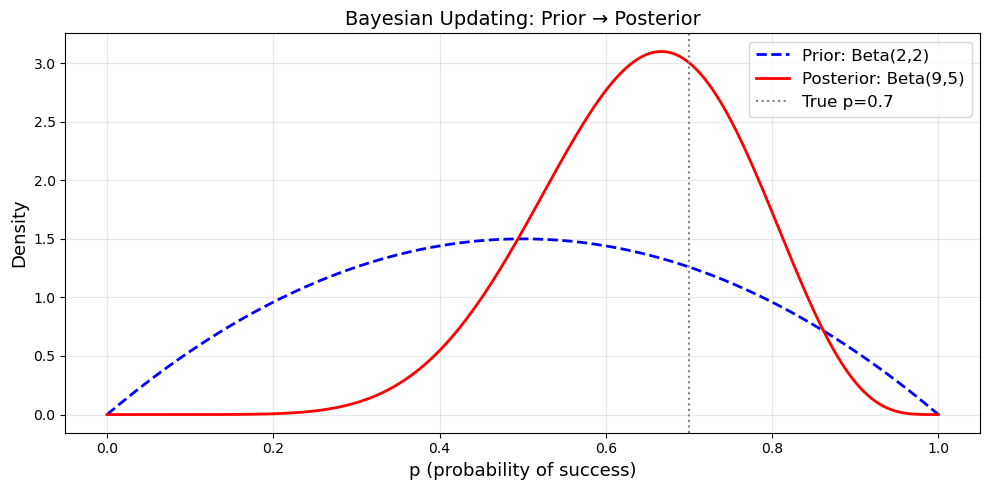

In [3]:
from scipy.stats import beta

# Prior: Beta(2, 2) — mild belief around 0.5
a_prior, b_prior = 2, 2

# Observed data: 7 successes out of 10 trials
successes, failures = 7, 3

# Posterior: Beta(a_prior + successes, b_prior + failures)
a_post = a_prior + successes
b_post = b_prior + failures

x = np.linspace(0, 1, 200)
plt.figure(figsize=(10, 5))
plt.plot(x, beta.pdf(x, a_prior, b_prior), 'b--', lw=2, label=f'Prior: Beta({a_prior},{b_prior})')
plt.plot(x, beta.pdf(x, a_post, b_post), 'r-', lw=2, label=f'Posterior: Beta({a_post},{b_post})')
plt.axvline(x=0.7, color='gray', ls=':', lw=1.5, label='True p=0.7')
plt.xlabel('p (probability of success)', fontsize=13)
plt.ylabel('Density', fontsize=13)
plt.title('Bayesian Updating: Prior → Posterior', fontsize=14)
plt.legend(fontsize=12); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
#### **8 - Central Limit Theorem (CLT)**

The CLT states that the **distribution of sample means** approaches a normal distribution as $n \to \infty$, regardless of the original distribution.

$$\bar{X}_n \xrightarrow{d} N\left(\mu, \frac{\sigma^2}{n}\right)$$

<font color='blue'>**Example) Demonstrate CLT using dice rolls**</font>

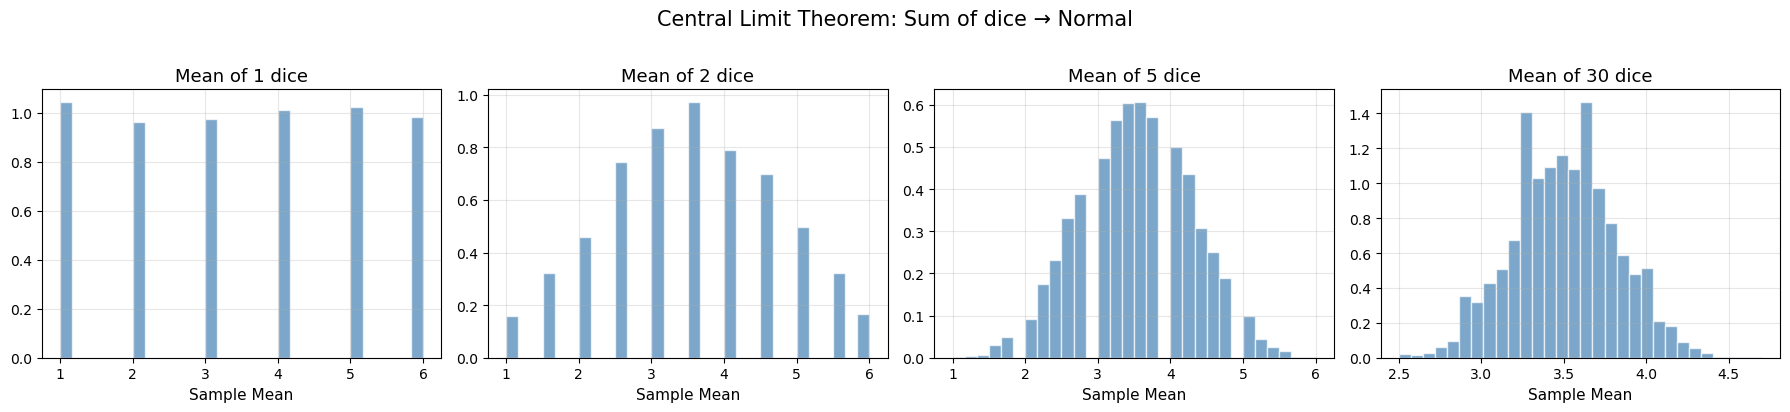

In [4]:
def dice_simulation(num_dice, num_rolls):
    results = []
    for _ in range(num_rolls):
        rolls = np.random.randint(1, 7, num_dice)
        results.append(np.mean(rolls))
    return results

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, n_dice in zip(axes, [1, 2, 5, 30]):
    data = dice_simulation(n_dice, 5000)
    ax.hist(data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title(f'Mean of {n_dice} dice', fontsize=13)
    ax.set_xlabel('Sample Mean', fontsize=11)
    ax.grid(True, alpha=0.3)
plt.suptitle('Central Limit Theorem: Sum of dice → Normal', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

---
#### **9 - Confidence Interval**

##### **9.1 - Definition**

A **confidence interval** gives a range of values that is likely to contain the true population parameter.

$$\text{CI} = \bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

For a 95% confidence interval, $z_{0.025} \approx 1.96$.

##### **9.2 - Visualization**

<font color='blue'>**Example) 95% confidence intervals for different sample sizes**</font>

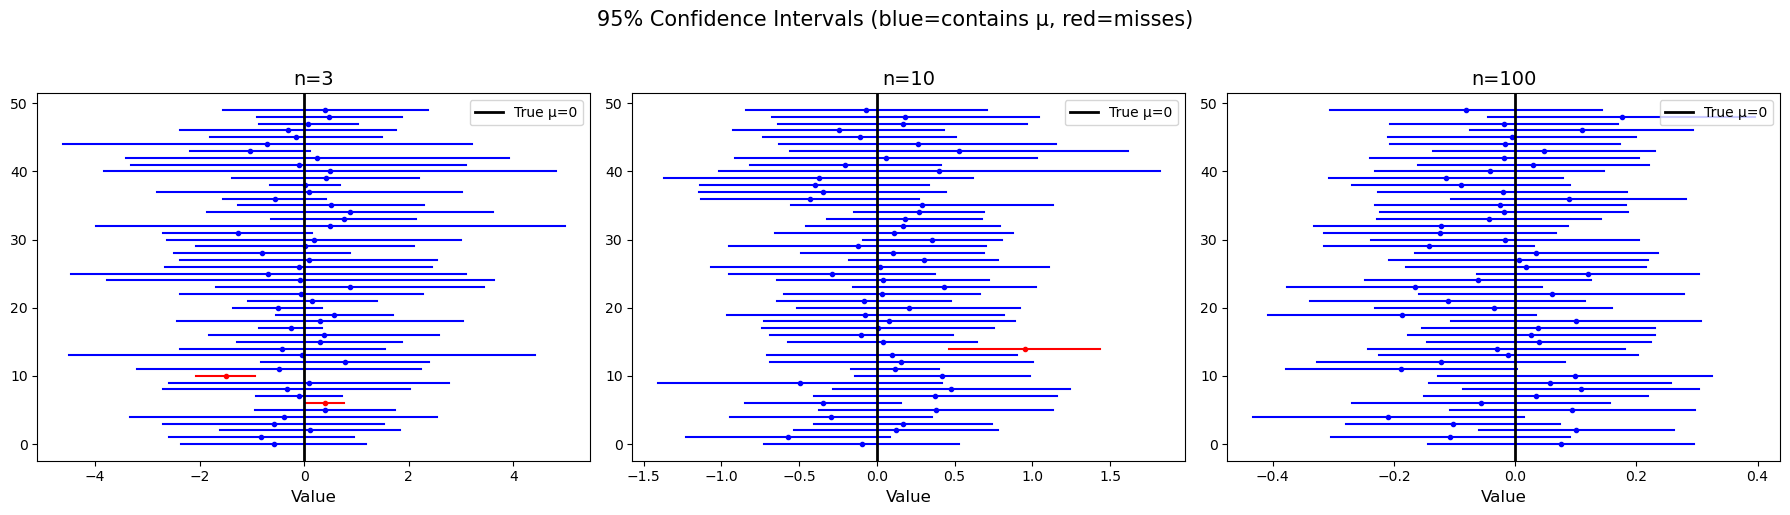

In [5]:
import scipy.stats as st

n_samples_list = [3, 10, 100]
n_rep = 50
alpha = 0.95

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, n_sample in zip(axes, n_samples_list):
    for i in range(n_rep):
        data = np.random.randn(n_sample)  # true mean=0, std=1
        ci = st.t.interval(confidence=alpha, df=n_sample-1,
                          loc=np.mean(data), scale=st.sem(data))
        color = 'blue' if ci[0] <= 0 <= ci[1] else 'red'
        ax.plot([ci[0], ci[1]], [i, i], color=color, linewidth=1.5)
        ax.plot(np.mean(data), i, 'o', color=color, markersize=3)
    ax.axvline(0, color='black', linewidth=2, label='True μ=0')
    ax.set_title(f'n={n_sample}', fontsize=14)
    ax.set_xlabel('Value', fontsize=12)
    ax.legend(fontsize=10)
plt.suptitle('95% Confidence Intervals (blue=contains μ, red=misses)', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

---
#### **10 - Likelihood**

##### **10.1 - Definition**

While **probability** asks "given parameters, how probable is the data?",  
**likelihood** asks "given data, how plausible are the parameters?"

$$\mathcal{L}(\theta | \text{data}) = P(\text{data} | \theta)$$

The key difference: in likelihood, $\theta$ varies while data is fixed.

##### **10.2 - Visualizing Likelihood**

<font color='blue'>**Example) Small vs Large likelihood — fitting a normal distribution to data**</font>

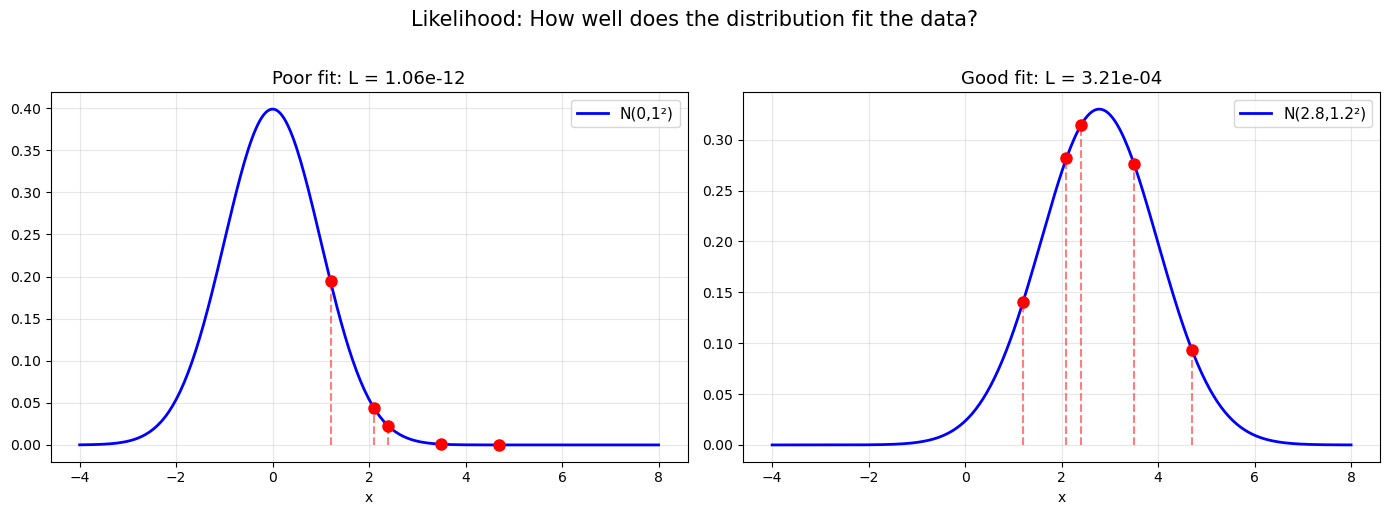

Likelihood improved by 302070407x with proper parameters!


In [11]:
from scipy.stats import norm

pdf_normal = norm.pdf

x_data = np.array([2.4, 1.2, 3.5, 2.1, 4.7])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Case 1: Poor fit (mu=0, sigma=1)
mu1, sigma1 = 0, 1
x_range = np.linspace(-4, 8, 300)
axes[0].plot(x_range, pdf_normal(x_range, mu1, sigma1), 'b-', lw=2, label=f'N({mu1},{sigma1}²)')
for xd in x_data:
    axes[0].plot(xd, pdf_normal(xd, mu1, sigma1), 'ro', markersize=8)
    axes[0].vlines(xd, 0, pdf_normal(xd, mu1, sigma1), colors='red', linestyles='--', alpha=0.5)
L1 = np.prod(pdf_normal(x_data, mu1, sigma1))
axes[0].set_title(f'Poor fit: L = {L1:.2e}', fontsize=13)
axes[0].set_xlabel('x'); axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

# Case 2: Good fit (mu=mean, sigma=std)
mu2, sigma2 = np.mean(x_data), np.std(x_data)
axes[1].plot(x_range, pdf_normal(x_range, mu2, sigma2), 'b-', lw=2, label=f'N({mu2:.1f},{sigma2:.1f}²)')
for xd in x_data:
    axes[1].plot(xd, pdf_normal(xd, mu2, sigma2), 'ro', markersize=8)
    axes[1].vlines(xd, 0, pdf_normal(xd, mu2, sigma2), colors='red', linestyles='--', alpha=0.5)
L2 = np.prod(pdf_normal(x_data, mu2, sigma2))
axes[1].set_title(f'Good fit: L = {L2:.2e}', fontsize=13)
axes[1].set_xlabel('x'); axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.suptitle('Likelihood: How well does the distribution fit the data?', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()
print(f'Likelihood improved by {L2/L1:.0f}x with proper parameters!')

##### **10.3 - Likelihood as a Function of Parameters**

<font color='blue'>**Example) Plot likelihood as a function of σ (with μ fixed at sample mean)**</font>

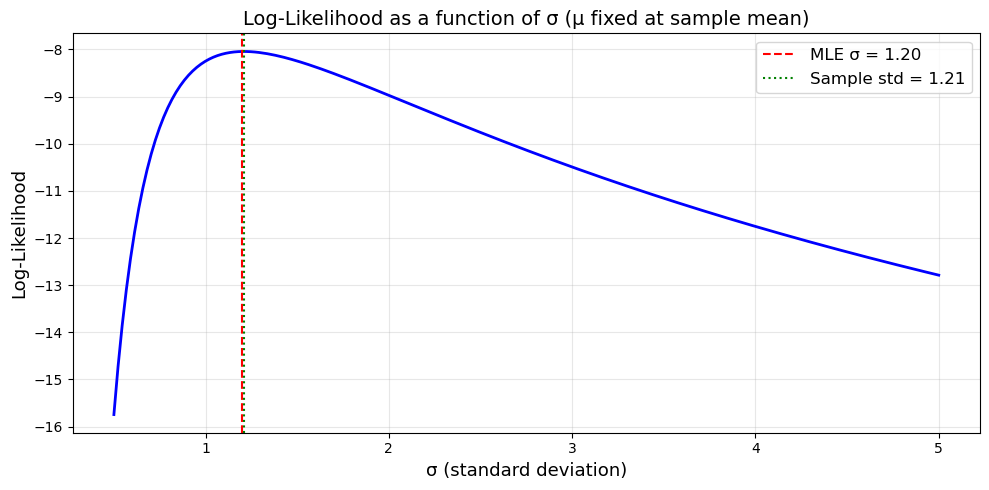

In [12]:
x_data = np.array([2.4, 1.2, 3.5, 2.1, 4.7])
mu = np.mean(x_data)
sigma_range = np.linspace(0.5, 5, 200)

# Compute log-likelihood for each sigma
log_likelihoods = []
for s in sigma_range:
    ll = np.sum(np.log(pdf_normal(x_data, mu, s)))
    log_likelihoods.append(ll)

plt.figure(figsize=(10, 5))
plt.plot(sigma_range, log_likelihoods, 'b-', linewidth=2)
best_sigma = sigma_range[np.argmax(log_likelihoods)]
plt.axvline(best_sigma, color='r', ls='--', lw=1.5, label=f'MLE σ = {best_sigma:.2f}')
plt.axvline(np.std(x_data), color='green', ls=':', lw=1.5, label=f'Sample std = {np.std(x_data):.2f}')
plt.xlabel('σ (standard deviation)', fontsize=13)
plt.ylabel('Log-Likelihood', fontsize=13)
plt.title('Log-Likelihood as a function of σ (μ fixed at sample mean)', fontsize=14)
plt.legend(fontsize=12); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
##### **Reference**
- S01: [Difference between Probability and Statistics](https://medium.com/towards-data-science/)
- S02: [Top 6 Basic Probability Distributions](https://medium.com/)
- S03: [Misinterpreting Continuous Probability Distributions](https://blog.dailydoseofds.com/)
- S04: [Understanding the Covariance Matrix](https://medium.com/towards-data-science/)
- S05: [Joint, Marginal, and Conditional Probabilities](https://blog.dailydoseofds.com/)
- S06: [Bayesian Statistics: An Introduction](https://aaweg-i.medium.com/)
- S07: [Probability vs. Likelihood](https://blog.dailydoseofds.com/)

---
**📌 Submission**: Complete all exercises → `Restart Kernel and Run All` → Save (`Ctrl+S`) → Submit via e-campus.